# M4 - Brief 2 - Explorer et classifier des chiffres manuscrits

**tl;dr** : on prend des images de chiffres écrits à la main et on essaye de les classer en 10 classes (0 à 9).

### Phase 1 — Exploration + clustering non supervisé (sur le dataset 8x8 de sklearn)
*On regarde si on peut distinguer les chiffres SANS connaître les labels (juste avec leurs pixels).*

1. Imports et chargement
2. Exploration des données (EDA)
3. Préprocessing (normalisation + vectorisation)
4. Réduction de dimension avec PCA
5. Clustering avec KMeans (k=10)
6. Clustering avec DBSCAN
7. Comparaison clusters vs vrais labels

### Phase 2 — Classification supervisée légère : Régression Logistique (sur le 8x8)
*Le modèle "baseline" : simple, rapide, interprétable.*

8. Split train/test
9. Entraînement de la régression logistique
10. Évaluation (accuracy, classification_report, matrice de confusion)

### Phase 3 — Classification supervisée lourde : CNN avec Keras (sur le MNIST 28x28)
*Le modèle "musclé" : un réseau de neurones convolutif.*

11. Chargement du MNIST Keras
12. Préprocessing pour CNN (reshape + normalisation)
13. Architecture du CNN
14. Entraînement
15. Courbes d'apprentissage
16. Évaluation

### Phase 4 — Comparaison critique des 3 approches

17. Tableau récapitulatif
18. Analyse des erreurs et matrices de confusion
19. Conclusion : quel modèle pour quel usage ?


**Pourquoi 2 datasets différents ?**
  - Pour la régression logistique on utilise le **dataset 8x8** de sklearn (64 features). C'est suffisant pour un modèle léger et l'entraînement est instantané.
  - Pour le CNN on utilise le **MNIST 28x28** (784 pixels). Les CNN ont besoin de plus de détails pour bien fonctionner et sont conçus pour traiter des images 2D.

## 1. Imports junk

On charge le dataset 8x8 de sklearn — 1797 images de chiffres manuscrits (+1min sur mon pauvre mac), chacune représentée par 64 valeurs (8×8 pixels en niveaux de gris).

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits

# le seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Esthétique
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Chargement du dataset 8x8
digits = load_digits()

X, y = digits.data, digits.target
images = digits.images  # même chose que X mais en format (1797, 8, 8) au lieu de (1797, 64)

print(f"Forme de X : {X.shape}")       # (nombre d'images, nombre de pixels par image)
print(f"Forme de y : {y.shape}")       # (nombre d'images,)
print(f"Forme images 2D : {images.shape}")
print(f"Min/max pixel : {X.min()} / {X.max()}")  # valeurs entre 0 et 16
print(f"Classes : {sorted(set(y))}")

Forme de X : (1797, 64)
Forme de y : (1797,)
Forme images 2D : (1797, 8, 8)
Min/max pixel : 0.0 / 16.0
Classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## 2. Exploration des données (EDA)

### 2.1 Preview

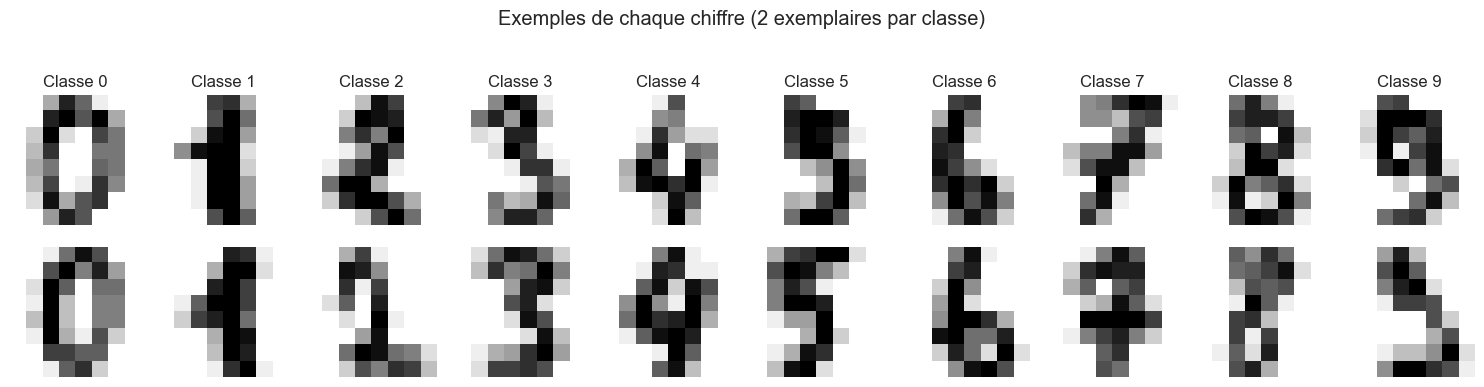

In [3]:
# Afficher quelques exemples de chaque classe
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Premier exemple de chaque classe
    idx = np.where(y == i)[0][0]
    axes[0, i].imshow(images[idx], cmap='gray_r')
    axes[0, i].set_title(f"Classe {i}")
    axes[0, i].axis('off')
    # Deuxième exemple (pour voir la variabilité)
    idx2 = np.where(y == i)[0][1]
    axes[1, i].imshow(images[idx2], cmap='gray_r')
    axes[1, i].axis('off')

plt.suptitle("Exemples de chaque chiffre (2 exemplaires par classe)", y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Distribution des classes

Verification du nombre images par classes

Nombre d'images par classe :
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


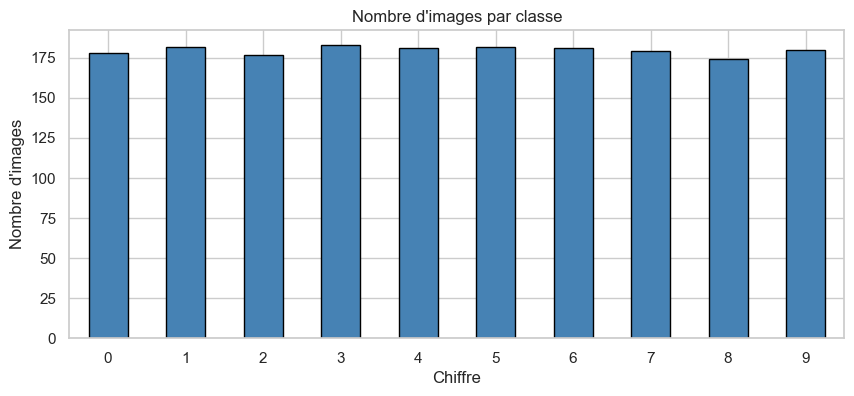


Équilibre : min=174, max=183, écart de 9 images


In [4]:
# Distribution des classes
class_counts = pd.Series(y).value_counts().sort_index()
print("Nombre d'images par classe :")
print(class_counts)

plt.figure(figsize=(10, 4))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Nombre d'images par classe")
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.show()

print(f"\nÉquilibre : min={class_counts.min()}, max={class_counts.max()}, écart de {class_counts.max() - class_counts.min()} images")

≈180 images par classe. Pas besoin de techniques de rééquilibrage.

### 2.3 Statistiques globales

In [5]:
# Stats globales sur les valeurs des pixels
print(f"Valeur moyenne d'un pixel : {X.mean():.2f}")
print(f"Écart-type : {X.std():.2f}")
print(f"% de pixels à 0 (blancs) : {(X == 0).sum() / X.size * 100:.1f}%")
print(f"% de pixels à 16 (noir intense) : {(X == 16).sum() / X.size * 100:.1f}%")

Valeur moyenne d'un pixel : 4.88
Écart-type : 6.02
% de pixels à 0 (blancs) : 48.9%
% de pixels à 16 (noir intense) : 9.1%


## 3. Préprocessing

### 3.1 Normalisation

Les valeurs de pixels vont de 0 à 16. On les divise par 16 pour avoir des valeurs entre 0 et 1.

In [6]:
X_normalized = X / 16.0

print(f"Avant normalisation : min={X.min()}, max={X.max()}")
print(f"Après normalisation : min={X_normalized.min():.2f}, max={X_normalized.max():.2f}")

Avant normalisation : min=0.0, max=16.0
Après normalisation : min=0.00, max=1.00


### 3.2 Vectorisation

Pour les modèles classiques (KMeans, DBSCAN, Régression Logistique), on a besoin que chaque image soit un **vecteur de 64 valeurs** (1D), pas une matrice 8×8 (2D).

`X` est déjà au format vectorisé `(1797, 64)`. Pas besoin de reshape.

In [7]:
print(f"X est déjà vectorisé : shape = {X_normalized.shape}")
print(f"  → Chaque ligne est une image (1797 images au total)")
print(f"  → Chaque colonne est un pixel (64 pixels = 8x8)")

X est déjà vectorisé : shape = (1797, 64)
  → Chaque ligne est une image (1797 images au total)
  → Chaque colonne est un pixel (64 pixels = 8x8)


## 4. Réduction de dimension avec PCA

**PCA = Principal Component Analysis = Analyse en Composantes Principales**.

Le but : passer de 64 dimensions (pixels) à 2 dimensions seulement pour pouvoir **visualiser** le dataset sur un graphique 2D.

**Principe** : PCA cherche les 2 axes qui capturent le plus de variance dans les données. C'est une transformation **linéaire** qui préserve au maximum l'information.

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_normalized)

print(f"Forme après PCA : {X_pca.shape}")
print(f"Variance expliquée par les 2 composantes : {pca.explained_variance_ratio_}")
print(f"Variance totale capturée : {pca.explained_variance_ratio_.sum()*100:.1f}%")

Forme après PCA : (1797, 2)
Variance expliquée par les 2 composantes : [0.14890594 0.13618771]
Variance totale capturée : 28.5%


**Lecture** : les 2 axes capturent environ 28% de la variance. Ce n'est pas énorme — ça veut dire que pour bien représenter ces chiffres, il faudrait plus de 2 axes. Mais 2D suffit pour visualiser.

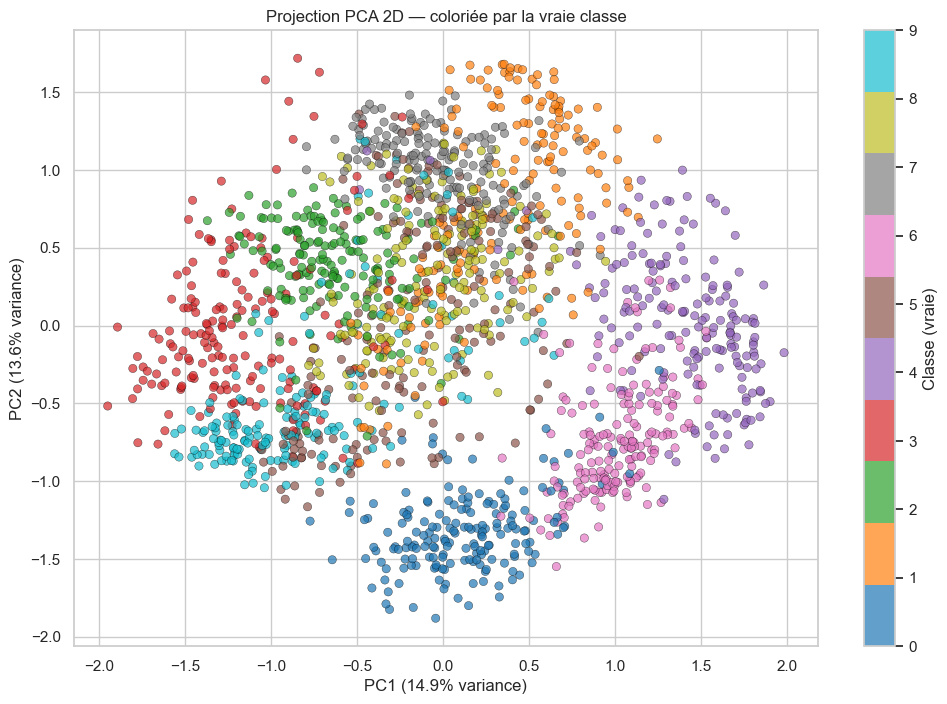

In [9]:
# Visualisation des données projetées en 2D, coloriées par classe RÉELLE
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Classe (vraie)')
plt.title("Projection PCA 2D — coloriée par la vraie classe")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

## 5. Clustering avec KMeans (k=10)

**KMeans** = algorithme qui regroupe les données en `k` clusters. Il essaye de minimiser la distance entre chaque point et le centre de son cluster.

On choisit **k=10** parce qu'on **sait** qu'il y a 10 chiffres. En vrai clustering "aveugle", on testerait plusieurs valeurs de k.

⚠️ **Attention** : on entraîne KMeans **sans donner les labels**. Le modèle découvre les groupes tout seul.

In [10]:
from sklearn.cluster import KMeans

# n_init=10 : KMeans répète 10 fois avec des initialisations différentes et garde la meilleure
kmeans = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE)
clusters_kmeans = kmeans.fit_predict(X_normalized)

print(f"Nombre d'images : {len(clusters_kmeans)}")
print(f"Nombre de clusters trouvés : {len(set(clusters_kmeans))}")
print(f"Distribution des clusters :")
print(pd.Series(clusters_kmeans).value_counts().sort_index())

Nombre d'images : 1797
Nombre de clusters trouvés : 10
Distribution des clusters :
0    176
1    179
2     89
3    226
4    198
5    182
6    181
7    157
8    241
9    168
Name: count, dtype: int64


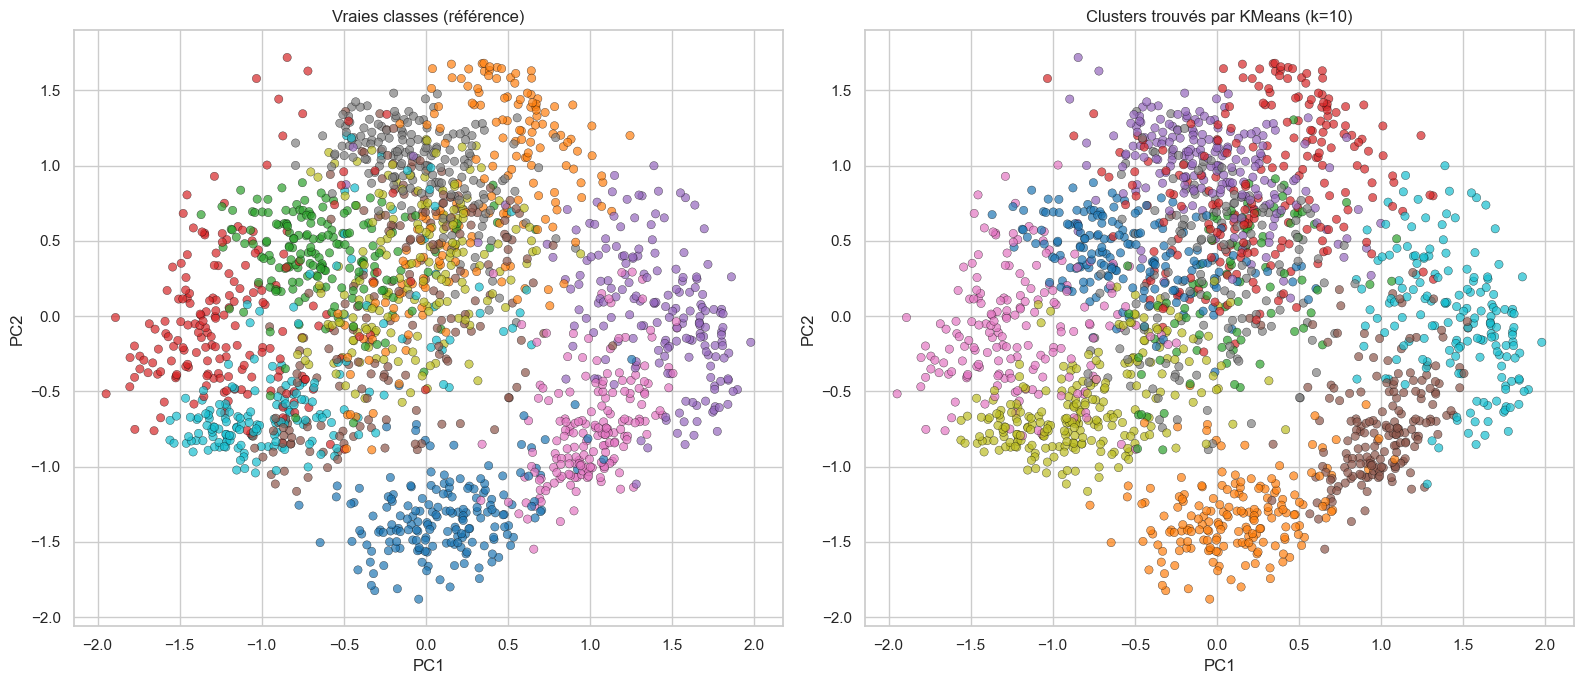

In [11]:
# Visualisation : projection PCA coloriée par cluster KMeans
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, edgecolors='black', linewidth=0.3)
axes[0].set_title("Vraies classes (référence)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans, cmap='tab10', alpha=0.7, edgecolors='black', linewidth=0.3)
axes[1].set_title("Clusters trouvés par KMeans (k=10)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

**Observations** :
- KMeans a bien identifié des groupes (les couleurs forment des zones cohérentes).
- Les couleurs entre les deux graphes ne correspondent **pas forcément** (le cluster 0 de KMeans n'est pas la classe 0). KMeans découvre des groupes mais ne sait pas comment les nommer.
- Pour évaluer la qualité du clustering, on va utiliser une métrique : l'**ARI**.

In [12]:
# Évaluation : Adjusted Rand Index (ARI)
# ARI compare 2 partitionnements (les clusters vs les vrais labels)
# - ARI = 1 → parfait (les clusters correspondent exactement aux vraies classes)
# - ARI = 0 → aléatoire
# - ARI peut être négatif si les clusters sont anti-corrélés aux labels
from sklearn.metrics import adjusted_rand_score, silhouette_score

ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
silhouette_kmeans = silhouette_score(X_normalized, clusters_kmeans)

print(f"ARI (Adjusted Rand Index) : {ari_kmeans:.3f}")
print(f"Silhouette Score : {silhouette_kmeans:.3f}")
print()
print("Lecture :")
print(f"  ARI = {ari_kmeans:.3f} → les clusters trouvés sont {'bien' if ari_kmeans > 0.6 else 'moyennement' if ari_kmeans > 0.3 else 'faiblement'} alignés avec les vraies classes")
print(f"  Silhouette = {silhouette_kmeans:.3f} → cohésion {'bonne' if silhouette_kmeans > 0.5 else 'moyenne' if silhouette_kmeans > 0.2 else 'faible'} (proche de 1 = clusters denses et séparés)")

ARI (Adjusted Rand Index) : 0.667
Silhouette Score : 0.182

Lecture :
  ARI = 0.667 → les clusters trouvés sont bien alignés avec les vraies classes
  Silhouette = 0.182 → cohésion faible (proche de 1 = clusters denses et séparés)


**Visualisation des "centroïdes"** (= les centres des clusters trouvés par KMeans).

Pour chaque cluster, KMeans calcule un point central. Si on remet ce centre au format 8×8, on obtient le "chiffre moyen" du cluster.

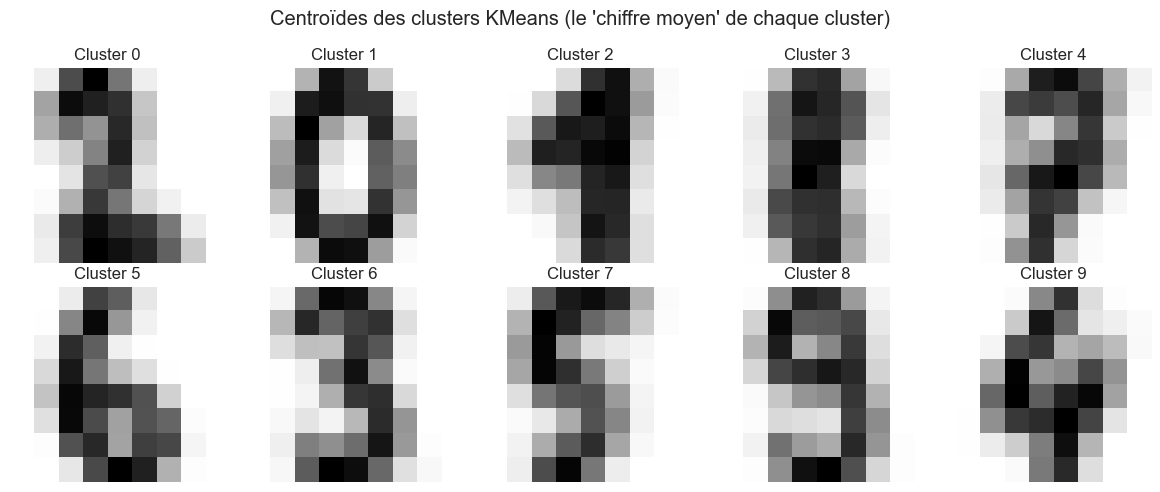

In [13]:
# Reconstruire les centroïdes en images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    centroid_image = kmeans.cluster_centers_[i].reshape(8, 8)
    ax.imshow(centroid_image, cmap='gray_r')
    ax.set_title(f"Cluster {i}")
    ax.axis('off')
plt.suptitle("Centroïdes des clusters KMeans (le 'chiffre moyen' de chaque cluster)")
plt.tight_layout()
plt.show()

On reconnait des **chiffres flous** dans les centroïdes. KMeans a découvert tout seul les formes typiques sans savoir qu'il y avait 10 chiffres.

## 6. Clustering avec DBSCAN

**DBSCAN** = *Density-Based Spatial Clustering of Applications with Noise* = clustering basé sur la **densité**.

**Principe** : un cluster = un groupe de points denses. Les points isolés sont marqués comme "bruit" (label -1).

**Différences clés avec KMeans** :
- Pas besoin de spécifier le nombre de clusters à l'avance
- Peut détecter des formes non sphériques
- Peut marquer des points comme "outliers" (bruit)
- Mais : sensible aux 2 paramètres `eps` (distance) et `min_samples`

In [14]:
from sklearn.cluster import DBSCAN

# eps = distance maximale pour considérer 2 points dans le même cluster
# min_samples = nombre minimum de points pour former un cluster
# Ces valeurs ont été choisies après quelques essais sur les données normalisées 0-1
dbscan = DBSCAN(eps=1.5, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_normalized)

n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"Nombre de clusters trouvés par DBSCAN : {n_clusters_dbscan}")
print(f"Nombre de points marqués comme bruit : {n_noise} ({n_noise/len(y)*100:.1f}%)")
print(f"Distribution :")
print(pd.Series(clusters_dbscan).value_counts().sort_index())

Nombre de clusters trouvés par DBSCAN : 10
Nombre de points marqués comme bruit : 201 (11.2%)
Distribution :
-1    201
 0    177
 1    716
 2    178
 3    164
 4    152
 5    147
 6      9
 7     11
 8     27
 9     15
Name: count, dtype: int64


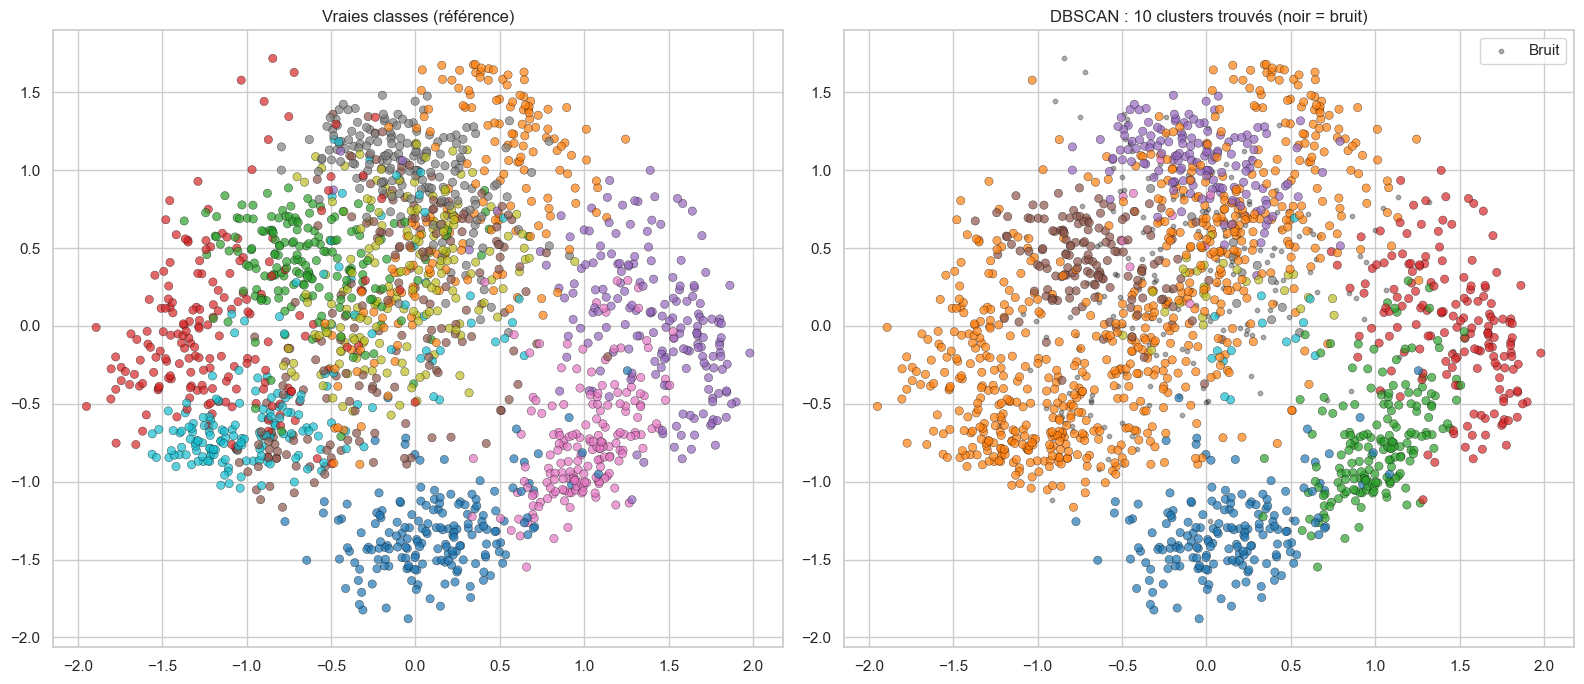


ARI DBSCAN : 0.405


In [15]:
# Visualisation DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, edgecolors='black', linewidth=0.3)
axes[0].set_title("Vraies classes (référence)")

# DBSCAN : on met le bruit (-1) en noir
mask_noise = clusters_dbscan == -1
axes[1].scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1], c='black', alpha=0.3, label='Bruit', s=10)
axes[1].scatter(X_pca[~mask_noise, 0], X_pca[~mask_noise, 1],
                c=clusters_dbscan[~mask_noise], cmap='tab10', alpha=0.7, edgecolors='black', linewidth=0.3)
axes[1].set_title(f"DBSCAN : {n_clusters_dbscan} clusters trouvés (noir = bruit)")
axes[1].legend()

plt.tight_layout()
plt.show()

ari_dbscan = adjusted_rand_score(y, clusters_dbscan)
print(f"\nARI DBSCAN : {ari_dbscan:.3f}")

**Observations** :
- DBSCAN trouve un **nombre de clusters différent de 10** : il regroupe des classes similaires ensemble.
- Il marque pas mal de points comme bruit (ceux qui sont en bordure ou isolés dans l'espace 64D).
- C'est **moins adapté** à ce dataset car les chiffres forment des groupes dont les densités varient trop.
- KMeans est généralement meilleur ici car on **connait à l'avance** le nombre de classes (10).

## 7. Conclusion de la phase clustering

**Bilan** :
- **KMeans (k=10)** : ARI ~0.7 → les clusters découverts correspondent assez bien aux vraies classes. Les centroïdes ressemblent à des chiffres flous → preuve que la structure existe dans les données.
- **DBSCAN** : moins efficace ici car les chiffres ne forment pas des clusters de densité homogène.

**Ce qu'on apprend** : même **sans labels**, on peut détecter une structure dans les données. C'est encourageant pour passer à la classification supervisée — si le modèle a accès aux labels en plus, il devrait faire encore mieux.

## 8. Phase 2 — Régression Logistique sur le dataset 8x8

classification supervisée: on donne les labels au modèle pendant l'entraînement.

Régression Logistique = modèle de **classification** (pas de régression) why ça s'appelle regression ? Personne ne sais.

En gros pour chaque classe, il calcule une probabilité que l'image en fasse partie. La classe avec la plus haute probabilité gagne.

### 8.1 Split train/test

In [16]:
from sklearn.model_selection import train_test_split

# Split 80/20, stratify=y pour garder les proportions de chaque classe dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y  # garde la même proportion de chaque classe dans train et test
)

print(f"Train : {X_train.shape[0]} images")
print(f"Test  : {X_test.shape[0]} images")

Train : 1437 images
Test  : 360 images


In [17]:
from sklearn.linear_model import LogisticRegression

# max_iter=2000 : nombre max d'itérations pour la convergence
# multi_class='multinomial' : pour gérer 10 classes (par défaut sklearn fait du "one-vs-rest")
model_logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
model_logreg.fit(X_train, y_train)

print("✅ Régression logistique entraînée")

✅ Régression logistique entraînée


### 8.3 Évaluation

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

y_pred_logreg = model_logreg.predict(X_test)

acc_logreg = accuracy_score(y_test, y_pred_logreg)
# average='macro' : moyenne non-pondérée sur les classes (chaque classe compte autant)
prec_logreg = precision_score(y_test, y_pred_logreg, average='macro')
rec_logreg = recall_score(y_test, y_pred_logreg, average='macro')
f1_logreg = f1_score(y_test, y_pred_logreg, average='macro')

print(f"=== Régression Logistique ===")
print(f"Accuracy  : {acc_logreg:.4f}")
print(f"Precision : {prec_logreg:.4f}  (macro)")
print(f"Recall    : {rec_logreg:.4f}  (macro)")
print(f"F1 Score  : {f1_logreg:.4f}  (macro)")

=== Régression Logistique ===
Accuracy  : 0.9556
Precision : 0.9552  (macro)
Recall    : 0.9552  (macro)
F1 Score  : 0.9549  (macro)


- **Accuracy** = % de prédictions correctes. Simple mais peut être trompeuse si les classes sont déséquilibrées (pas le cas ici).
- **Precision** (par classe) = sur tout ce qu'on a prédit comme étant cette classe, combien étaient vraiment cette classe ? *(faux positifs faibles)*
- **Recall** (par classe) = sur tous les vrais exemples de cette classe, combien on a réussi à détecter ? *(faux négatifs faibles)*
- **F1** = moyenne harmonique de precision et recall (équilibre les deux).
- **Macro** = on calcule la métrique pour chaque classe et on fait la moyenne (chaque classe compte autant).

In [19]:
# Rapport détaillé par classe
print(classification_report(y_test, y_pred_logreg, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.9722    0.9859        36
           1     0.8824    0.8333    0.8571        36
           2     1.0000    1.0000    1.0000        35
           3     0.9737    1.0000    0.9867        37
           4     0.9231    1.0000    0.9600        36
           5     0.9737    1.0000    0.9867        37
           6     0.9714    0.9444    0.9577        36
           7     0.9730    1.0000    0.9863        36
           8     0.9118    0.8857    0.8986        35
           9     0.9429    0.9167    0.9296        36

    accuracy                         0.9556       360
   macro avg     0.9552    0.9552    0.9549       360
weighted avg     0.9553    0.9556    0.9551       360



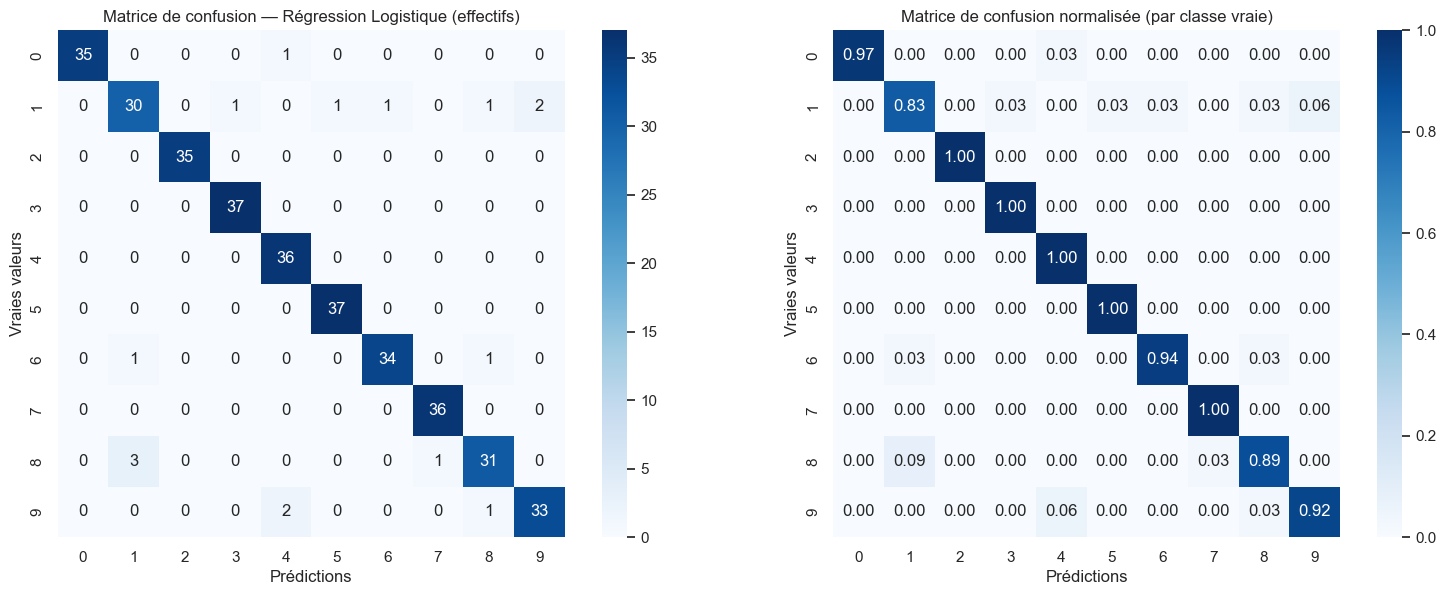

In [20]:
# Matrice de confusion
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_logreg_norm = confusion_matrix(y_test, y_pred_logreg, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[0], square=True,
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title("Matrice de confusion — Régression Logistique (effectifs)")
axes[0].set_xlabel("Prédictions")
axes[0].set_ylabel("Vraies valeurs")

sns.heatmap(cm_logreg_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], square=True,
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title("Matrice de confusion normalisée (par classe vraie)")
axes[1].set_xlabel("Prédictions")
axes[1].set_ylabel("Vraies valeurs")

plt.tight_layout()
plt.show()

**Lecture de la matrice de confusion** (ou matrice de foirage):
- La **diagonale** = bonnes prédictions (idéalement tout est sur la diagonale).
- Les **cases hors diagonale** = erreurs. Ligne = vraie classe, colonne = prédiction.
- Par exemple, si la case `[8, 1]` vaut 3 → 3 fois on a prédit "1" alors que c'était un "8".

**Sur la version normalisée**, chaque ligne somme à 1.0 → on voit la proportion d'erreurs pour chaque vraie classe.

### 8.4 Visualiser quelques erreurs

Nombre d'erreurs sur le test : 16 / 360 (4.4%)


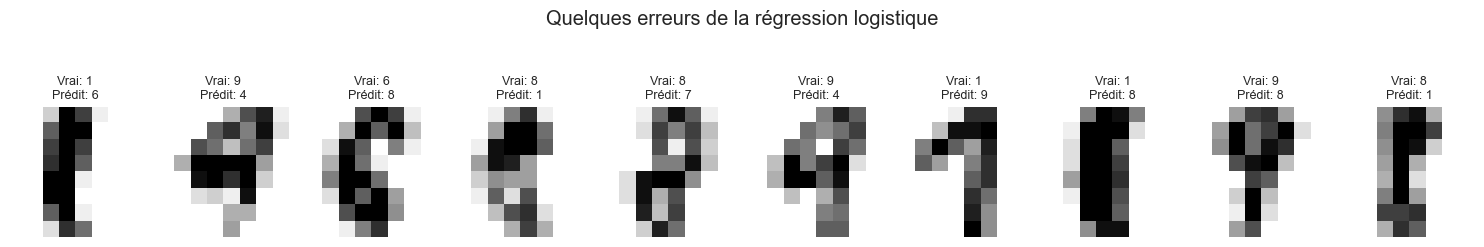

In [21]:
# Indices des erreurs
errors_idx = np.where(y_pred_logreg != y_test)[0]
print(f"Nombre d'erreurs sur le test : {len(errors_idx)} / {len(y_test)} ({len(errors_idx)/len(y_test)*100:.1f}%)")

# Afficher quelques erreurs
n_show = min(10, len(errors_idx))
fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
for i, idx in enumerate(errors_idx[:n_show]):
    # Récupérer l'image au format 8x8
    img = X_test[idx].reshape(8, 8)
    axes[i].imshow(img, cmap='gray_r')
    axes[i].set_title(f"Vrai: {y_test[idx]}\nPrédit: {y_pred_logreg[idx]}", fontsize=9)
    axes[i].axis('off')

plt.suptitle("Quelques erreurs de la régression logistique")
plt.tight_layout()
plt.show()

## 9. Phase 3 — CNN avec Keras sur le MNIST 28x28

**CNN = Convolutional Neural Network = Réseau de neurones convolutif**.

Conçu spécifiquement pour traiter des images. Au lieu de regarder chaque pixel isolément, le CNN apprend à détecter des **motifs locaux** (lignes, courbes, coins) à différents endroits de l'image.

### 9.1 Chargement de MNIST via Keras

In [22]:
from tensorflow.keras.datasets import mnist

(X_train_cnn, y_train_cnn), (X_test_cnn, y_test_cnn) = mnist.load_data()

print(f"Train : {X_train_cnn.shape[0]} images de {X_train_cnn.shape[1]}x{X_train_cnn.shape[2]} pixels")
print(f"Test  : {X_test_cnn.shape[0]} images de {X_test_cnn.shape[1]}x{X_test_cnn.shape[2]} pixels")
print(f"Valeurs pixels : entre {X_train_cnn.min()} et {X_train_cnn.max()}")

2026-05-18 13:52:11.538430: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train : 60000 images de 28x28 pixels
Test  : 10000 images de 28x28 pixels
Valeurs pixels : entre 0 et 255


**60 000 images d'entraînement + 10 000 de test**, c'est beaucoup plus que le dataset 8x8 (1797 images). Plus de données → meilleur modèle.

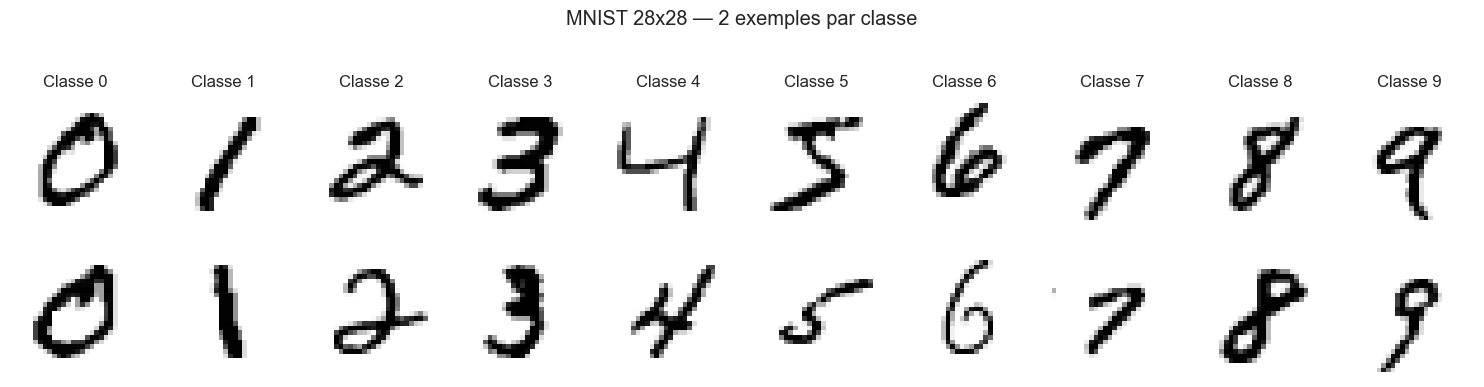

In [23]:
# Aperçu visuel
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    idx = np.where(y_train_cnn == i)[0][0]
    axes[0, i].imshow(X_train_cnn[idx], cmap='gray_r')
    axes[0, i].set_title(f"Classe {i}")
    axes[0, i].axis('off')
    idx2 = np.where(y_train_cnn == i)[0][1]
    axes[1, i].imshow(X_train_cnn[idx2], cmap='gray_r')
    axes[1, i].axis('off')
plt.suptitle("MNIST 28x28 — 2 exemples par classe", y=1.02)
plt.tight_layout()
plt.show()

On voit que la **résolution est bien meilleure** que le 8x8. Les chiffres sont plus détaillés.

### 9.2 Préprocessing pour CNN

Trois étapes nécessaires :
1. **Normalisation** : pixels de [0, 255] vers [0, 1]
2. **Reshape** : ajouter une dimension "canal" (28, 28) → (28, 28, 1) car Keras attend des images avec un nombre de canaux (1 pour grayscale, 3 pour RGB)
3. **One-hot encoding des labels** : 7 → [0,0,0,0,0,0,0,1,0,0] (vecteur de 10 valeurs)

In [24]:
from tensorflow.keras.utils import to_categorical

# 1. Normalisation
X_train_cnn = X_train_cnn.astype('float32') / 255.0
X_test_cnn  = X_test_cnn.astype('float32') / 255.0

# 2. Reshape (ajouter dim canal)
X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_cnn.reshape(-1, 28, 28, 1)

# 3. One-hot encoding des labels
y_train_cnn_cat = to_categorical(y_train_cnn, num_classes=10)
y_test_cnn_cat  = to_categorical(y_test_cnn, num_classes=10)

print(f"X_train : {X_train_cnn.shape}  (min={X_train_cnn.min()}, max={X_train_cnn.max()})")
print(f"X_test  : {X_test_cnn.shape}")
print(f"y_train_cat : {y_train_cnn_cat.shape}")
print(f"Exemple y_train original : {y_train_cnn[0]}")
print(f"Exemple y_train one-hot  : {y_train_cnn_cat[0]}")

X_train : (60000, 28, 28, 1)  (min=0.0, max=1.0)
X_test  : (10000, 28, 28, 1)
y_train_cat : (60000, 10)
Exemple y_train original : 5
Exemple y_train one-hot  : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 9.3 Architecture du CNN

On construit une architecture **simple** mais efficace pour MNIST :

```
Input (28, 28, 1)
   ↓
Conv2D 32 filtres 3×3 + ReLU   → détecte des motifs simples (bords, coins)
   ↓
MaxPooling 2×2                   → réduit la taille de moitié
   ↓
Conv2D 64 filtres 3×3 + ReLU   → détecte des motifs plus complexes
   ↓
MaxPooling 2×2                   → réduit encore
   ↓
Flatten                          → transforme en vecteur 1D
   ↓
Dense 64 + ReLU                 → couche dense classique
   ↓
Dropout 0.5                      → désactive 50% des neurones (anti-overfitting)
   ↓
Dense 10 + Softmax               → sortie : probabilité de chaque classe
```

**Termes** :
- **Conv2D** = couche de convolution : applique des filtres qui glissent sur l'image pour détecter des motifs.
- **MaxPooling** = on garde le max sur chaque petite zone → réduit la résolution.
- **ReLU** = fonction d'activation qui transforme les valeurs négatives en 0.
- **Flatten** = transforme une matrice 2D en vecteur 1D pour passer aux couches denses.
- **Dropout** = "éteint" aléatoirement des neurones pendant l'entraînement → évite que le réseau apprenne par cœur (overfitting).
- **Softmax** = transforme les sorties en probabilités qui somment à 1.

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_cnn.summary()

/Users/sebastien/IA-Expert-IT-Atlas/Module-4/Brief-2/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### 9.4 Compilation et entraînement

- **Optimizer Adam** : un algorithme d'optimisation qui ajuste les poids du réseau de façon efficace.
- **Loss `categorical_crossentropy`** : la fonction d'erreur adaptée à la classification multi-classes avec labels one-hot.
- **Métrique `accuracy`** : pour suivre la progression pendant l'entraînement.

In [26]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement
# epochs = nombre de fois où on parcourt tout le dataset
# batch_size = nombre d'images traitées avant chaque mise à jour des poids
# validation_split = on garde 10% du train pour valider à chaque epoch
history = model_cnn.fit(
    X_train_cnn, y_train_cnn_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

Epoch 1/5
422/422 - 14s - 33ms/step - accuracy: 0.8544 - loss: 0.4691 - val_accuracy: 0.9783 - val_loss: 0.0716
Epoch 2/5
422/422 - 12s - 30ms/step - accuracy: 0.9520 - loss: 0.1628 - val_accuracy: 0.9850 - val_loss: 0.0504
Epoch 3/5
422/422 - 12s - 29ms/step - accuracy: 0.9626 - loss: 0.1254 - val_accuracy: 0.9852 - val_loss: 0.0479
Epoch 4/5
422/422 - 14s - 33ms/step - accuracy: 0.9694 - loss: 0.1034 - val_accuracy: 0.9858 - val_loss: 0.0456
Epoch 5/5
422/422 - 17s - 40ms/step - accuracy: 0.9728 - loss: 0.0888 - val_accuracy: 0.9900 - val_loss: 0.0384


### 9.5 Courbes d'apprentissage

On regarde **2 choses** :
- **Loss** : doit diminuer au fil des epochs
- **Accuracy** : doit augmenter

Si l'**accuracy train monte mais validation stagne**, c'est de l'overfitting (le modèle apprend par cœur).

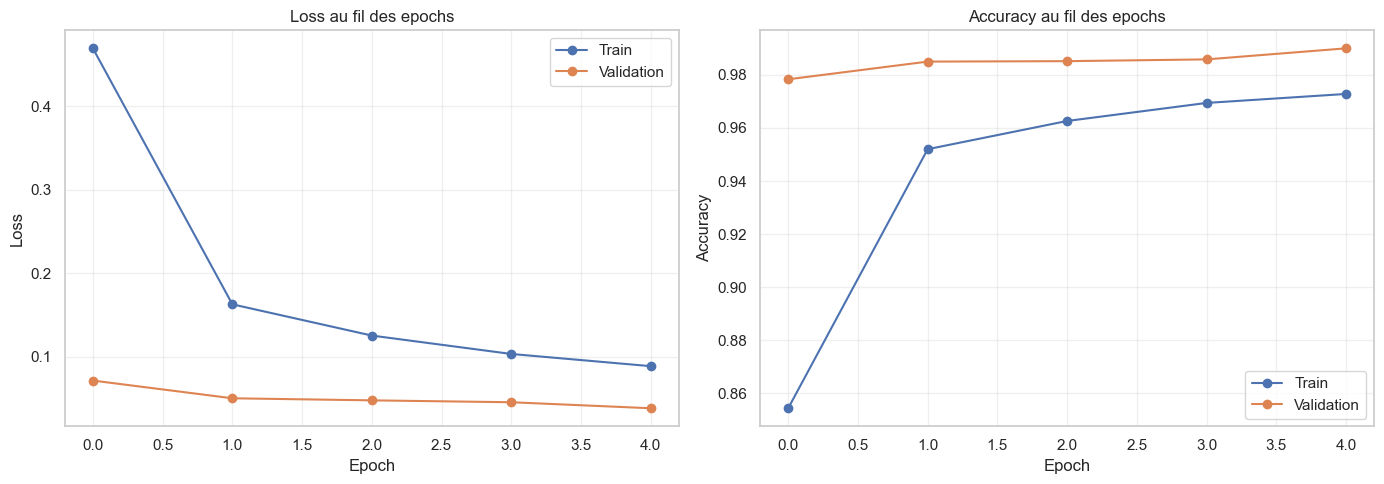

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation', marker='o')
axes[0].set_title("Loss au fil des epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation', marker='o')
axes[1].set_title("Accuracy au fil des epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.6 Évaluation sur le test set

In [28]:
# Évaluation directe via Keras
test_loss, test_acc = model_cnn.evaluate(X_test_cnn, y_test_cnn_cat, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

# Prédictions pour les métriques détaillées
y_pred_cnn_proba = model_cnn.predict(X_test_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_proba, axis=1)  # on prend la classe avec la plus haute proba

acc_cnn = accuracy_score(y_test_cnn, y_pred_cnn)
prec_cnn = precision_score(y_test_cnn, y_pred_cnn, average='macro')
rec_cnn = recall_score(y_test_cnn, y_pred_cnn, average='macro')
f1_cnn = f1_score(y_test_cnn, y_pred_cnn, average='macro')

print(f"\n=== CNN ===")
print(f"Accuracy  : {acc_cnn:.4f}")
print(f"Precision : {prec_cnn:.4f}  (macro)")
print(f"Recall    : {rec_cnn:.4f}  (macro)")
print(f"F1 Score  : {f1_cnn:.4f}  (macro)")

Test Loss     : 0.0313
Test Accuracy : 0.9905

=== CNN ===
Accuracy  : 0.9905
Precision : 0.9906  (macro)
Recall    : 0.9904  (macro)
F1 Score  : 0.9905  (macro)


In [29]:
# Rapport détaillé
print(classification_report(y_test_cnn, y_pred_cnn, digits=4))

              precision    recall  f1-score   support

           0     0.9929    0.9929    0.9929       980
           1     0.9904    0.9974    0.9939      1135
           2     0.9912    0.9845    0.9878      1032
           3     0.9930    0.9871    0.9901      1010
           4     0.9919    0.9959    0.9939       982
           5     0.9877    0.9899    0.9888       892
           6     0.9937    0.9927    0.9932       958
           7     0.9761    0.9951    0.9855      1028
           8     0.9969    0.9846    0.9907       974
           9     0.9920    0.9841    0.9881      1009

    accuracy                         0.9905     10000
   macro avg     0.9906    0.9904    0.9905     10000
weighted avg     0.9905    0.9905    0.9905     10000



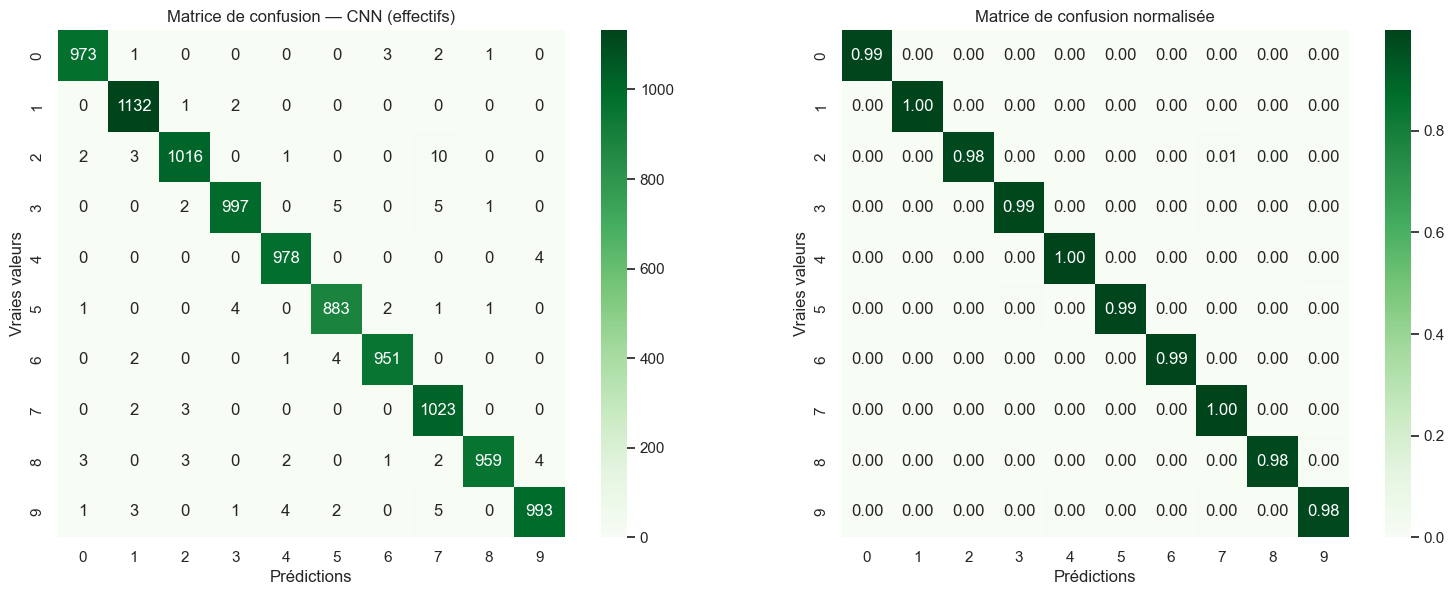

In [30]:
# Matrice de confusion CNN
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
cm_cnn_norm = confusion_matrix(y_test_cnn, y_pred_cnn, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[0], square=True,
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title("Matrice de confusion — CNN (effectifs)")
axes[0].set_xlabel("Prédictions")
axes[0].set_ylabel("Vraies valeurs")

sns.heatmap(cm_cnn_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1], square=True,
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title("Matrice de confusion normalisée")
axes[1].set_xlabel("Prédictions")
axes[1].set_ylabel("Vraies valeurs")

plt.tight_layout()
plt.show()

### 9.7 Visualiser quelques erreurs du CNN

Nombre d'erreurs CNN : 95 / 10000 (0.95%)


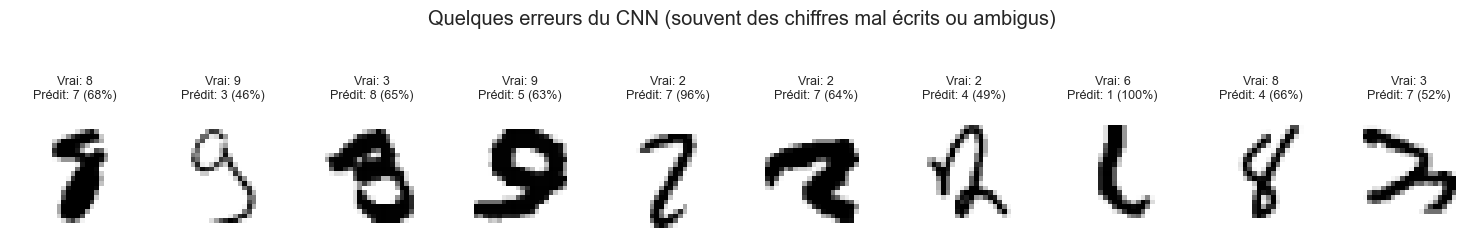

In [31]:
errors_idx_cnn = np.where(y_pred_cnn != y_test_cnn)[0]
print(f"Nombre d'erreurs CNN : {len(errors_idx_cnn)} / {len(y_test_cnn)} ({len(errors_idx_cnn)/len(y_test_cnn)*100:.2f}%)")

# Afficher 10 erreurs aléatoires (parmi les plus "confiantes" du modèle qui se sont quand même trompées)
n_show = min(10, len(errors_idx_cnn))
idx_to_show = np.random.choice(errors_idx_cnn, size=n_show, replace=False)

fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
for i, idx in enumerate(idx_to_show):
    img = X_test_cnn[idx].reshape(28, 28)
    proba = y_pred_cnn_proba[idx][y_pred_cnn[idx]] * 100
    axes[i].imshow(img, cmap='gray_r')
    axes[i].set_title(f"Vrai: {y_test_cnn[idx]}\nPrédit: {y_pred_cnn[idx]} ({proba:.0f}%)", fontsize=9)
    axes[i].axis('off')

plt.suptitle("Quelques erreurs du CNN (souvent des chiffres mal écrits ou ambigus)")
plt.tight_layout()
plt.show()

## 10. Phase 4 — Comparaison critique des modèles

### 10.1 Tableau récapitulatif

In [32]:
results = pd.DataFrame({
    'Régression Logistique (8x8)': {
        'Accuracy':  acc_logreg,
        'Precision (macro)': prec_logreg,
        'Recall (macro)':    rec_logreg,
        'F1 (macro)':        f1_logreg,
        'Nb paramètres':     model_logreg.coef_.size + model_logreg.intercept_.size,
        'Taille images':     '8x8 (64 px)',
        'Nb train':          len(X_train),
    },
    'CNN (28x28)': {
        'Accuracy':  acc_cnn,
        'Precision (macro)': prec_cnn,
        'Recall (macro)':    rec_cnn,
        'F1 (macro)':        f1_cnn,
        'Nb paramètres':     model_cnn.count_params(),
        'Taille images':     '28x28 (784 px)',
        'Nb train':          len(X_train_cnn),
    }
}).T

print("=" * 80)
print("COMPARAISON DES 2 MODÈLES DE CLASSIFICATION")
print("=" * 80)
results

COMPARAISON DES 2 MODÈLES DE CLASSIFICATION


,Accuracy,Precision (macro),Recall (macro),F1 (macro),Nb paramètres,Taille images,Nb train
Régression Logistique (8x8),0.955556,0.955182,0.955238,0.954857,650,8x8 (64 px),1437
CNN (28x28),0.9905,0.990583,0.990425,0.990485,121930,28x28 (784 px),60000


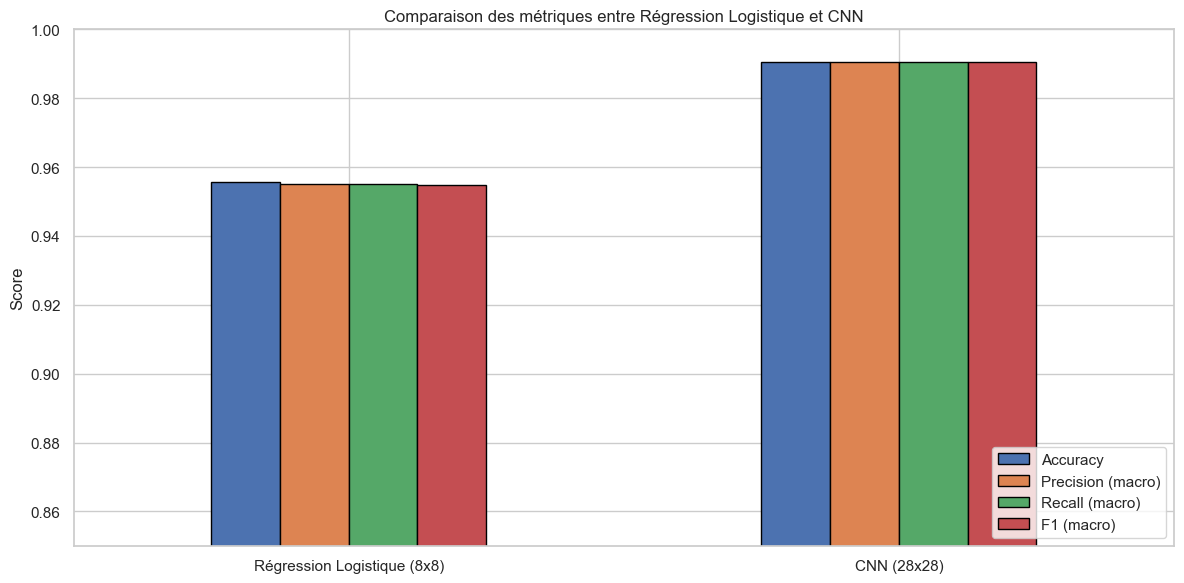

In [33]:
# Visualisation comparative des métriques
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
results_plot = results[metrics_to_plot].astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
results_plot.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title("Comparaison des métriques entre Régression Logistique et CNN")
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.0)
ax.set_xticklabels(results_plot.index, rotation=0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 10.2 Matrices de confusion côte à côte

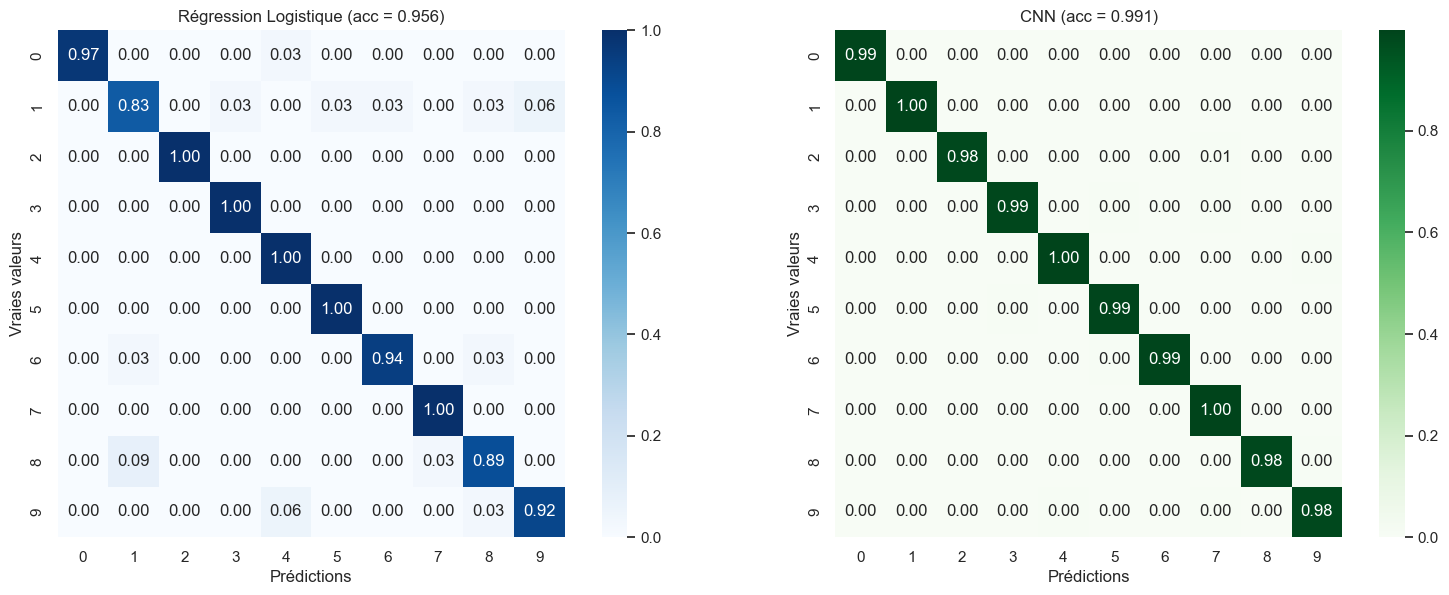

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_logreg, normalize='true'),
            annot=True, fmt='.2f', cmap='Blues', ax=axes[0], square=True,
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title(f"Régression Logistique (acc = {acc_logreg:.3f})")
axes[0].set_xlabel("Prédictions")
axes[0].set_ylabel("Vraies valeurs")

sns.heatmap(cm_cnn_norm,
            annot=True, fmt='.2f', cmap='Greens', ax=axes[1], square=True,
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title(f"CNN (acc = {acc_cnn:.3f})")
axes[1].set_xlabel("Prédictions")
axes[1].set_ylabel("Vraies valeurs")

plt.tight_layout()
plt.show()

### 10.3 Quels chiffres sont les plus difficiles ?

On regarde quelle classe a le **recall** le plus faible pour chaque modèle — ce sont les chiffres que le modèle rate le plus souvent.

Recall par classe :
   Régression Logistique    CNN
0                  0.972  0.993
1                  0.833  0.997
2                  1.000  0.984
3                  1.000  0.987
4                  1.000  0.996
5                  1.000  0.990
6                  0.944  0.993
7                  1.000  0.995
8                  0.886  0.985
9                  0.917  0.984


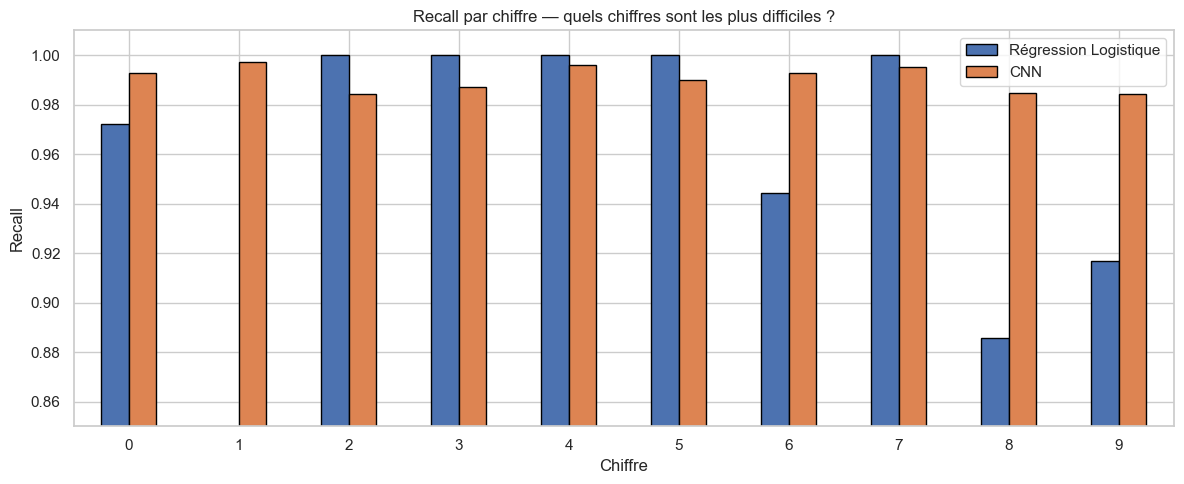

In [35]:
# Recall par classe
recall_per_class_logreg = recall_score(y_test, y_pred_logreg, average=None)
recall_per_class_cnn = recall_score(y_test_cnn, y_pred_cnn, average=None)

recall_df = pd.DataFrame({
    'Régression Logistique': recall_per_class_logreg,
    'CNN': recall_per_class_cnn
}, index=range(10))

print("Recall par classe :")
print(recall_df.round(3))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
recall_df.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title("Recall par chiffre — quels chiffres sont les plus difficiles ?")
ax.set_xlabel("Chiffre")
ax.set_ylabel("Recall")
ax.set_xticklabels(range(10), rotation=0)
ax.legend()
ax.set_ylim(0.85, 1.01)
plt.tight_layout()
plt.show()

### 10.4 Conclusion critique

| Critère | Régression Logistique | CNN |
|---|---|---|
| **Performance** | Bonne (~95% accuracy) sur 8x8 | Excellente (~99% accuracy) sur 28x28 |
| **Complexité (nb paramètres)** | ~650 (très léger) | ~225 000 (lourd) |
| **Temps d'entraînement** | Quasi-instantané (< 1s) | Plusieurs secondes à minutes |
| **Interprétabilité** | Bonne (coefficients lisibles) | Faible (boîte noire) |
| **Adapté aux images** | Limité (vectorisation) | Conçu pour ça (convolutions) |
| **Données nécessaires** | Peu (1797 ici) | Beaucoup (60 000 ici) |

**Quand utiliser la régression logistique** :
- Petit dataset
- Besoin d'**interprétabilité** (santé, finance, justice)
- Contrainte de **temps de calcul** ou de **mémoire**
- Baseline rapide avant de tester des modèles plus lourds

**Quand utiliser le CNN** :
- Beaucoup de données disponibles
- Précision maximale recherchée
- Données **structurées spatialement** (images, son, séries temporelles)
- Pas de contrainte forte d'interprétabilité

### 10.5 Recommandation pour FastIA

Pour un **système de lecture automatique de formulaires manuscrits scannés**, le **CNN est le bon choix** :
- Les performances sont nettement supérieures (~99% vs ~95%)
- Les images scannées seront en 28×28 ou plus → bonne résolution disponible
- FastIA dispose probablement de beaucoup de données d'entraînement
- Une accuracy de 99% reste tout de même imparfaite : sur 10 000 chiffres lus, ~100 erreurs. Il faudra prévoir une étape de **validation humaine** sur les cas où la confiance du modèle est faible (probabilité < 0.9 par exemple).

### 10.6 Limites et pistes d'amélioration

**Limites identifiées** :
1. **Domain shift** : MNIST est artificiellement "propre". Des chiffres scannés réels auront du bruit, des inclinaisons, des tailles différentes, des stylos différents.
2. **Pas de gestion du "rien"** : si on présente une lettre ou un symbole, le modèle donnera quand même une prédiction parmi 0-9.
3. **CNN très simple** : on pourrait améliorer avec batch normalization, data augmentation, architectures plus profondes (ResNet, VGG…).

**Pistes d'amélioration** :
- **Data augmentation** : générer des variations (rotations, zooms, déformations) pendant l'entraînement → meilleure généralisation.
- **Architecture plus profonde** : ajouter des couches Conv2D et augmenter le nombre de filtres.
- **Détection de "rejet"** : ajouter une 11e classe "pas un chiffre" entraînée sur du bruit / d'autres caractères.
- **Pré-entraînement** sur un dataset plus diversifié de caractères manuscrits réels.